In [1]:
import pandas as pd

clients = pd.read_csv('/content/clients (1).csv')
properties = pd.read_excel('/content/properties.xlsx')

print(clients.shape)
print(properties.shape)

(2000, 12)
(10000, 9)


In [2]:
clients.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [3]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB


In [4]:
clients['date_of_birth']=pd.to_datetime(clients['date_of_birth'], format='mixed', dayfirst=False)
clients['age']= 2026 - clients['date_of_birth'].dt.year
clients[['date_of_birth', 'age']].head()

,date_of_birth,age
0,1968-05-11,58
1,1962-11-26,64
2,1959-04-07,67
3,1959-11-25,67
4,1976-02-28,50


In [5]:
for col in ['client_type', 'gender', 'region', 'acquisition_purpose', 'loan_applied', 'referral_channel']:
  print(col, ':', clients[col].unique())

client_type : ['Individual' 'Company']
gender : ['F' 'M']
region : ['California' 'Quebec' 'Oregon' 'Arizona' 'Berlin' 'Nevada' 'Colorado'
 'Brussels' 'Mexico City' 'Krasnodar Krai' 'Utah' 'Northern Ireland'
 'Capital Region' 'Virginia' 'Wyoming' 'Kansas' 'Saint Petersburg'
 'Scotland' 'Novosibirsk' 'Ohio' 'Washington' 'England' 'Texas'
 'North Rhine-Westphalia' 'Florida' 'Ile-de-France' 'British Columbia'
 'Puebla' 'Provence' 'Hamburg' 'Ontario' 'Central Denmark' 'New York'
 'Manitoba' 'Nuevo Leon' 'Normandy' 'Flanders' 'Georgia' 'Zealand'
 'New South Wales' 'Tatarstan' 'Wales' 'Alberta' 'Baja California' 'Hesse'
 'Wallonia' 'Victoria' 'Jalisco' 'Brittany' 'Bavaria' 'North Denmark'
 'South Australia' 'Occitanie' 'Southern Denmark' 'Queensland'
 'Moscow Oblast' 'Western Australia']
acquisition_purpose : ['Home' 'Investment']
loan_applied : ['Yes' 'No']
referral_channel : ['Website' 'Agency' 'Client']


In [6]:
print('country :', clients['country'].unique())

country : ['USA' 'Canada' 'Germany' 'Belgium' 'Mexico' 'Russia' 'UK' 'Denmark'
 'France' 'Australia']


In [7]:
properties.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,2024-01-01,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,2024-01-01,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,2024-01-01,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,2024-01-01,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,2024-01-01,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [8]:
properties['sale_price'] = properties['sale_price'].replace('[\$,]', '', regex=True).astype(float)

properties[['sale_price']].head()

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_652/359207961.py:1: SyntaxWarning: invalid escape sequence '\$'
  properties['sale_price'] = properties['sale_price'].replace('[\$,]', '', regex=True).astype(float)


,sale_price
0,300385.62
1,208930.81
2,218585.92
3,246172.68
4,212265.67


In [9]:
sold= properties[properties['listing_status'] == 'Sold']
client_investment = sold.groupby('client_ref').agg(
    total_properties=('listing_id', 'count'),
    total_spend=('sale_price', 'sum'),
    avg_price=('sale_price', 'mean')
).reset_index()

client_investment.head()

,client_ref,total_properties,total_spend,avg_price
0,C0001,4,1246764.72,311691.180000
1,C0002,5,1841095.93,368219.186000
2,C0003,5,1661457.59,332291.518000
3,C0004,6,1608263.51,268043.918333
4,C0005,13,3653385.38,281029.644615


In [10]:
clients= clients.merge(client_investment, left_on='client_id', right_on='client_ref', how='left')
clients[['client_id', 'total_properties', 'total_spend', 'avg_price']].head()

,client_id,total_properties,total_spend,avg_price
0,C0001,4,1246764.72,311691.180000
1,C0002,5,1841095.93,368219.186000
2,C0003,5,1661457.59,332291.518000
3,C0004,6,1608263.51,268043.918333
4,C0005,13,3653385.38,281029.644615


In [11]:
clients[['total_properties', 'total_spend', 'avg_price']].isna().sum()

,0
total_properties,0
total_spend,0
avg_price,0


In [12]:
clients_encoded = pd.get_dummies(clients , columns = ['client_type', 'acquisition_purpose', 'loan_applied', 'referral_channel'], drop_first=True)
clients_encoded.shape

(2000, 18)

In [13]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_country = LabelEncoder()

clients_encoded['region_encoded'] = le_region.fit_transform(clients_encoded['region'])
clients_encoded['country_encoded'] = le_country.fit_transform(clients_encoded['country'])

clients_encoded[['region', 'region_encoded', 'country', 'country_encoded']].head()

,region,region_encoded,country,country_encoded
0,California,8,USA,9
1,California,8,USA,9
2,California,8,USA,9
3,California,8,USA,9
4,California,8,USA,9


In [14]:
from sklearn.preprocessing import StandardScaler

features_to_scale = ['age', 'satisfaction_score', 'total_properties', 'total_spend', 'avg_price', 'region_encoded', 'country_encoded']

scaler = StandardScaler()
clients_scaled = clients_encoded.copy()
clients_scaled[features_to_scale] = scaler.fit_transform(clients_encoded[features_to_scale])

clients_scaled[features_to_scale].head()

,age,satisfaction_score,total_properties,total_spend,avg_price,region_encoded,country_encoded
0,0.109635,0.687089,0.413942,-0.039140,-0.507841,-0.78866,0.457342
1,0.455668,-1.435740,1.605141,1.669967,0.303126,-0.78866,0.457342
2,0.628684,0.687089,1.605141,1.153384,-0.212303,-0.78866,0.457342
3,0.628684,1.394698,2.796340,1.000415,-1.134018,-0.78866,0.457342
4,-0.351743,1.394698,11.134734,6.881534,-0.947721,-0.78866,0.457342


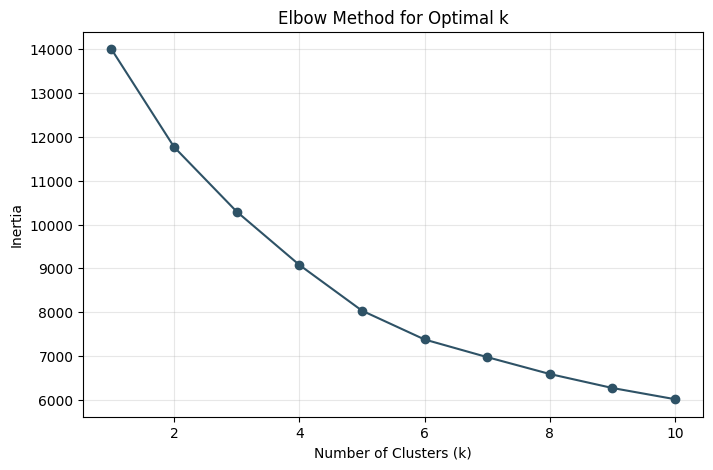

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = clients_scaled[features_to_scale]

inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o', color='#2E5266')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(alpha=0.3)
plt.show()

k=2, silhouette score=0.1552
k=3, silhouette score=0.1746
k=4, silhouette score=0.1763
k=5, silhouette score=0.1794
k=6, silhouette score=0.1686
k=7, silhouette score=0.1555
k=8, silhouette score=0.1539
k=9, silhouette score=0.1632
k=10, silhouette score=0.1626


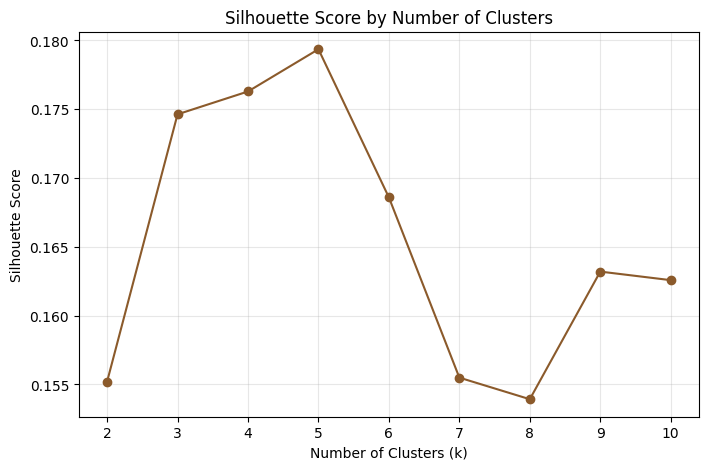

In [16]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range_sil = range(2, 11)  # silhouette needs at least 2 clusters

for k in K_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f'k={k}, silhouette score={score:.4f}')

plt.figure(figsize=(8,5))
plt.plot(K_range_sil, silhouette_scores, marker='o', color='#8B5A2B')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.grid(alpha=0.3)
plt.show()

In [17]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
clients_scaled['cluster'] = kmeans_final.fit_predict(X)
clients_encoded['cluster'] = clients_scaled['cluster']

clients_scaled['cluster'].value_counts()

,count
cluster,
0,680
2,578
3,444
1,248
4,50


In [18]:
cluster_summary = clients_encoded.groupby('cluster').agg(
    avg_age=('age', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    avg_total_properties=('total_properties', 'mean'),
    avg_total_spend=('total_spend', 'mean'),
    avg_price=('avg_price', 'mean'),
    pct_loan_applied=('loan_applied_Yes', 'mean'),
    pct_investment_purpose=('acquisition_purpose_Investment', 'mean'),
    pct_individual=('client_type_Individual', 'mean')
).round(2)

cluster_summary

,avg_age,avg_satisfaction,avg_total_properties,avg_total_spend,avg_price,pct_loan_applied,pct_investment_purpose,pct_individual
cluster,,,,,,,,
0,57.33,2.78,3.55,1064868.75,301313.41,0.36,0.31,0.95
1,53.79,3.03,3.47,1157150.71,335294.48,0.35,0.31,0.95
2,55.69,3.26,3.67,1515938.22,417497.40,0.37,0.30,0.95
3,55.11,3.06,3.47,1154559.45,333745.28,0.39,0.30,0.95
4,64.28,3.52,7.32,2416602.86,332747.25,0.32,0.34,0.96


In [19]:
print(cluster_summary[['pct_individual']])

region_by_cluster = clients_encoded.groupby('cluster')['country'].value_counts(normalize=True).groupby(level=0).head(3)
print(region_by_cluster)

         pct_individual
cluster                
0                  0.95
1                  0.95
2                  0.95
3                  0.95
4                  0.96
cluster  country
0        USA        0.916176
         UK         0.029412
         Mexico     0.025000
1        Canada     0.334677
         France     0.181452
         Belgium    0.169355
2        USA        0.868512
         UK         0.048443
         Germany    0.029412
3        USA        0.833333
         UK         0.099099
         Russia     0.040541
4        USA        0.860000
         UK         0.060000
         Belgium    0.020000
Name: proportion, dtype: float64


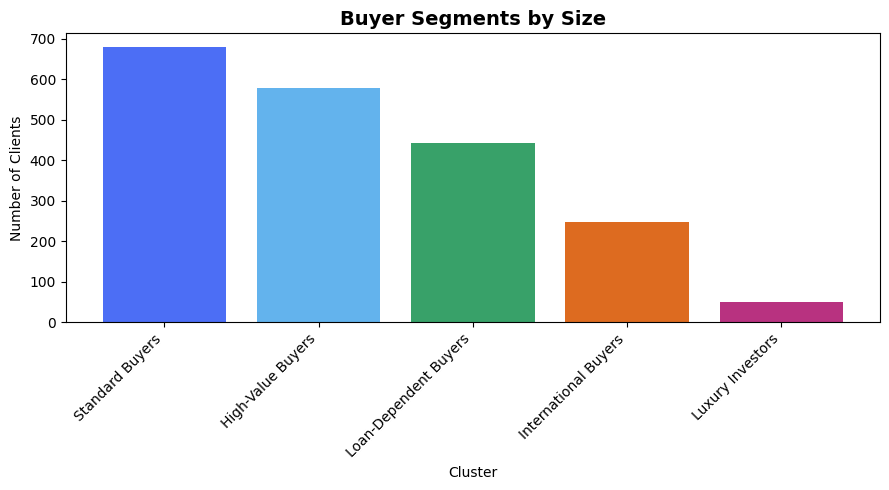

In [20]:
import matplotlib.pyplot as plt

cluster_names = {
    0: 'Standard Buyers',
    1: 'International Buyers',
    2: 'High-Value Buyers',
    3: 'Loan-Dependent Buyers',
    4: 'Luxury Investors'
}

cluster_counts = clients_encoded['cluster'].map(cluster_names).value_counts()

colors = ['#4C6EF5', '#63B3ED', '#38A169', '#DD6B20', '#B83280']

plt.figure(figsize=(9,5))
plt.bar(cluster_counts.index, cluster_counts.values, color=colors)
plt.title('Buyer Segments by Size', fontsize=14, fontweight='bold')
plt.ylabel('Number of Clients')
plt.xlabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

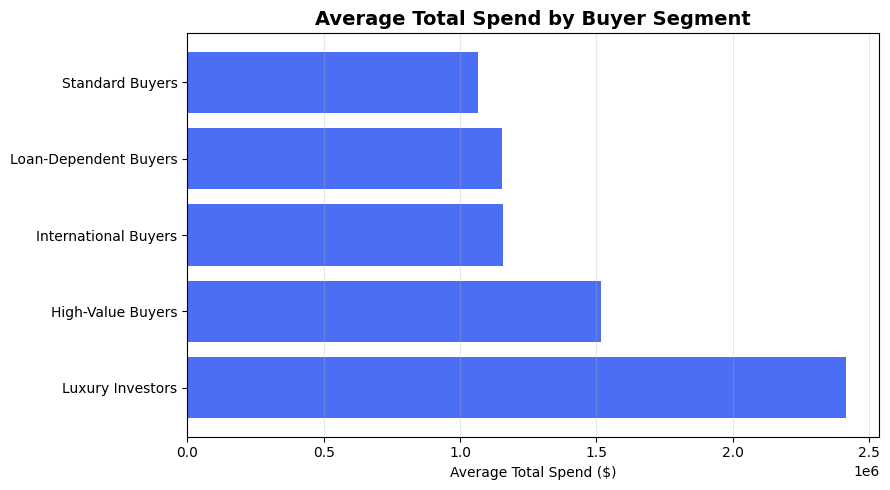

In [21]:
avg_spend_by_cluster = clients_encoded.groupby('cluster')['total_spend'].mean()
avg_spend_by_cluster.index = avg_spend_by_cluster.index.map(cluster_names)
avg_spend_by_cluster = avg_spend_by_cluster.sort_values(ascending=False)

plt.figure(figsize=(9,5))
plt.barh(avg_spend_by_cluster.index, avg_spend_by_cluster.values, color='#4C6EF5')
plt.title('Average Total Spend by Buyer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Average Total Spend ($)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

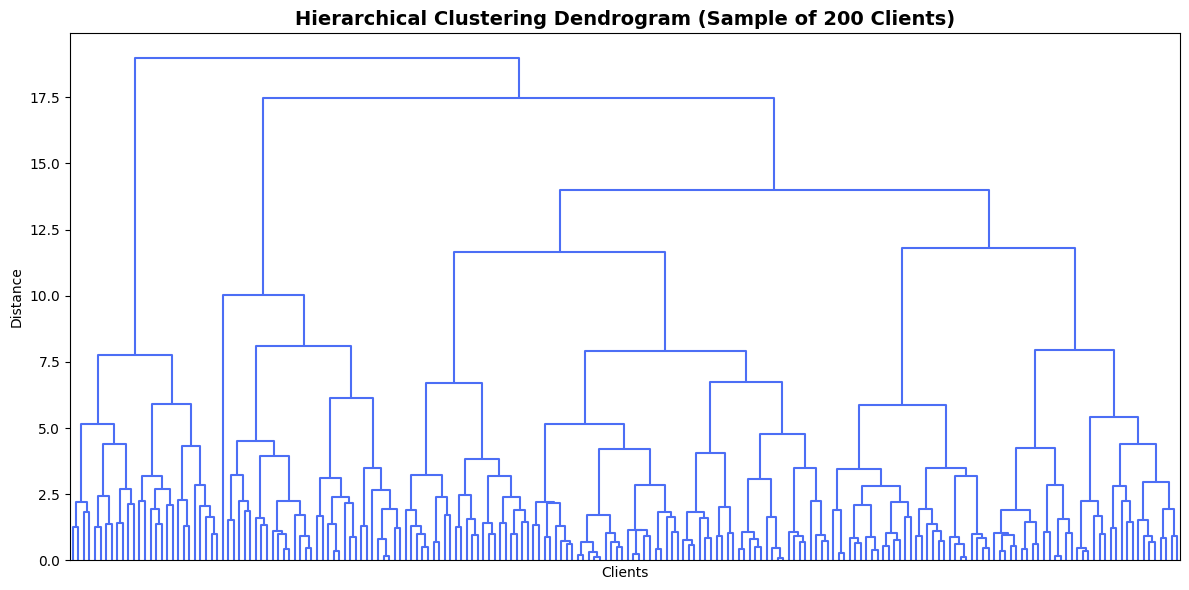

In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Hierarchical clustering works best on a sample when data is large - let's use a sample of 200 for a readable dendrogram
sample = clients_scaled[features_to_scale].sample(200, random_state=42)

linked = linkage(sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, no_labels=True, color_threshold=0, above_threshold_color='#4C6EF5')
plt.title('Hierarchical Clustering Dendrogram (Sample of 200 Clients)', fontsize=14, fontweight='bold')
plt.xlabel('Clients')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [23]:
from scipy.cluster.hierarchy import fcluster

hier_labels = fcluster(linked, t=5, criterion='maxclust')

import numpy as np
print('Hierarchical cluster sizes:', np.unique(hier_labels, return_counts=True))

Hierarchical cluster sizes: (array([1, 2, 3, 4, 5], dtype=int32), array([27, 33, 77, 29, 34]))


In [24]:
clients_encoded.to_csv('clients_final.csv', index=False)

from google.colab import files
files.download('clients_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# Financial Impact Analysis — calculating revenue concentration by segment
total_portfolio_value = clients_encoded['total_spend'].sum()
print(f"Total Portfolio Value: ${total_portfolio_value:,.0f}")

revenue_by_segment = clients_encoded.groupby('cluster').agg(
    client_count=('client_id', 'count'),
    total_revenue=('total_spend', 'sum')
)
revenue_by_segment['pct_of_clients'] = (revenue_by_segment['client_count'] / revenue_by_segment['client_count'].sum() * 100).round(1)
revenue_by_segment['pct_of_revenue'] = (revenue_by_segment['total_revenue'] / total_portfolio_value * 100).round(1)
revenue_by_segment['revenue_to_client_ratio'] = (revenue_by_segment['pct_of_revenue'] / revenue_by_segment['pct_of_clients']).round(2)
revenue_by_segment['segment'] = revenue_by_segment.index.map(cluster_names)

revenue_by_segment[['segment', 'client_count', 'pct_of_clients', 'total_revenue', 'pct_of_revenue', 'revenue_to_client_ratio']]

Total Portfolio Value: $2,520,750,961


,segment,client_count,pct_of_clients,total_revenue,pct_of_revenue,revenue_to_client_ratio
cluster,,,,,,
0,Standard Buyers,680,34.0,7.241108e+08,28.7,0.84
1,International Buyers,248,12.4,2.869734e+08,11.4,0.92
2,High-Value Buyers,578,28.9,8.762123e+08,34.8,1.20
3,Loan-Dependent Buyers,444,22.2,5.126244e+08,20.3,0.91
4,Luxury Investors,50,2.5,1.208301e+08,4.8,1.92


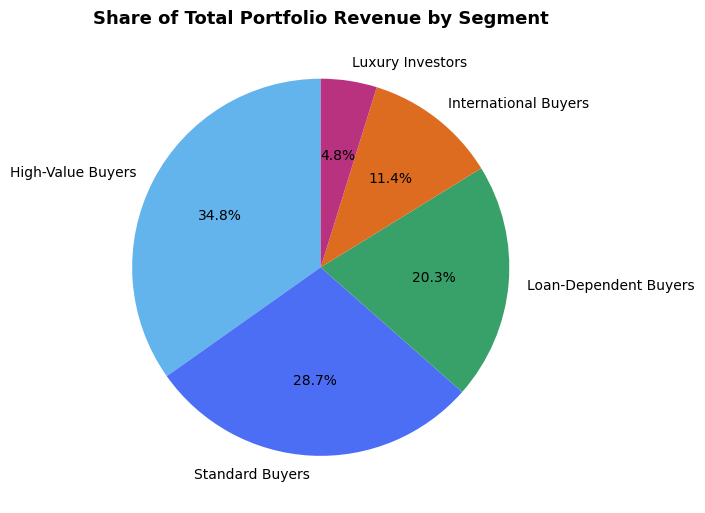

In [27]:
SEGMENT_COLORS = {
    "Standard Buyers": "#4C6EF5",
    "High-Value Buyers": "#63B3ED",
    "Loan-Dependent Buyers": "#38A169",
    "International Buyers": "#DD6B20",
    "Luxury Investors": "#B83280"
}

rev_sorted = revenue_by_segment.sort_values('pct_of_revenue', ascending=False)
colors_pie = [SEGMENT_COLORS[s] for s in rev_sorted['segment']]

plt.figure(figsize=(7,7))
plt.pie(rev_sorted['pct_of_revenue'], labels=rev_sorted['segment'], autopct='%1.1f%%', startangle=90, colors=colors_pie)
plt.title('Share of Total Portfolio Revenue by Segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Financial Impact Analysis

Beyond describing segment demographics, this section quantifies how total portfolio revenue is distributed
across segments, to identify which client relationships are disproportionately valuable on a per-client basis.